In [1]:
import pandas as pd

# The raw file uses '?' for missing values - tell pandas to read those as Nan
df = pd.read_csv('heart_disease.csv',na_values='?')
print('rows,columns:',df.shape)
df.head()

rows,columns: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [3]:
df = df.dropna()
df.shape

(297, 14)

In [4]:
df.num.value_counts()

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

In [5]:
df['target'] = (df['num']>0).astype(int)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop(columns = ['num','target'])
y = df['target']
x_scaled = scaler.fit_transform(X)
x_scaled[:2]

array([[ 0.93618065,  0.69109474, -2.24062879,  0.75038004, -0.27644339,
         2.43042728,  1.01019851,  0.01749443, -0.69641941,  1.06896529,
         2.26414539, -0.72197605,  0.65587737],
       [ 1.3789285 ,  0.69109474,  0.87388018,  1.59626645,  0.74455507,
        -0.41145029,  1.01019851, -1.81633388,  1.43591632,  0.38177332,
         0.6437811 ,  2.47842525, -0.89422007]])

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,stratify=y,random_state=42)

In [8]:
print('training patients:',X_train.shape[0])
print('test patients:',X_test.shape[0])

training patients: 237
test patients: 60


In [9]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_test,y_test)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test) # recall is more imp if person have disease model say no means effected low recall

print(classification_report(y_test,y_pred,target_names=['no disease (0)','disease (1) ']))

                precision    recall  f1-score   support

no disease (0)       0.94      1.00      0.97        32
  disease (1)        1.00      0.93      0.96        28

      accuracy                           0.97        60
     macro avg       0.97      0.96      0.97        60
  weighted avg       0.97      0.97      0.97        60



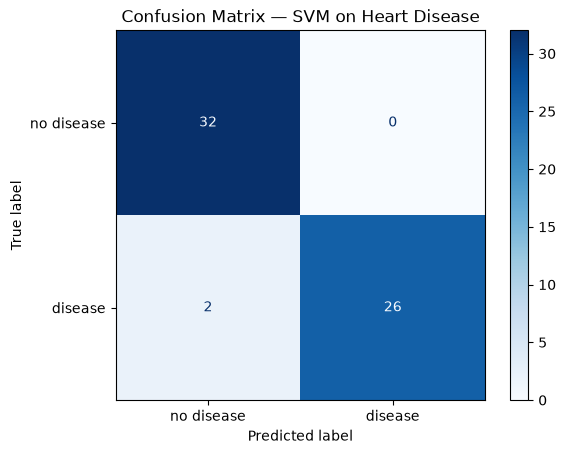

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['no disease', 'disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — SVM on Heart Disease')
plt.show()

In [13]:
# Train the same SVM with different C and gamma values and compare
configs = [
    (1.0, 'scale'),   # our original default
    (0.1, 'scale'),   # weaker C -> simpler, smoother boundary
    (10,  'scale'),   # stronger C -> fits training data harder
    (1.0, 0.01),      # small gamma -> very smooth boundary
    (10,  0.1),       # high C + high gamma -> most complex boundary
]

for C, gamma in configs:
    m = SVC(kernel='rbf', C=C, gamma=gamma)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f'===== C={C}, gamma={gamma}  |  accuracy={m.score(X_test, y_test):.3f} =====')
    print(classification_report(y_test, pred,
                                target_names=['no disease', 'disease']))

===== C=1.0, gamma=scale  |  accuracy=0.850 =====
              precision    recall  f1-score   support

  no disease       0.83      0.91      0.87        32
     disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

===== C=0.1, gamma=scale  |  accuracy=0.867 =====
              precision    recall  f1-score   support

  no disease       0.83      0.94      0.88        32
     disease       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60

===== C=10, gamma=scale  |  accuracy=0.833 =====
              precision    recall  f1-score   support

  no disease       0.82      0.88      0.85        32
     disease       0.85      0.79      0.81        28

    accuracy                     